# 08 — Friction and Thermal Feedback Model

**Project:** NeuRelux. Two parts: a physics-guided friction coefficient model compared against a black-box alternative, and a lumped thermal model demonstrating feedback from temperature back into friction — the last piece before Notebook 09 combines everything built so far.

## 1. Motivation

ATLAS's assumed model lists its friction model as Coulomb-type with an empirically-fit coefficient — "a major source of validation error." This notebook tests whether keeping the Coulomb relation itself hard-coded (never learned) while only learning the coefficient extrapolates better than learning the whole friction force from scratch, then closes the loop with the thermal feedback the brief calls for explicitly.

## 2. Physical problem

Braking force per pole is $F_R = \mu F_N$ (Coulomb friction, $F_N$ the normal/attraction force from Notebook 07), summed over poles. The coefficient $\mu$ is not a material constant in practice — it depends on velocity (Stribeck-type effects), temperature, and normal force itself. Resistive and frictional losses heat the magnet and rail, and that temperature feeds back into $\mu$ (and, in a fuller model, into rail conductivity — noted but not built here, see Section 12).

## 3. Governing equations

$$
F_{R,i} = \mu_i F_{A,i} \quad \text{(hard-coded, never learned)}, \qquad F_{R,\text{total}} = \sum_i \mu_i F_{A,i}
$$

$$
\mu = \mathrm{softplus}\!\left(\mu_\theta(v, F_N, T)\right)
$$

$$
C_{th}\frac{dT}{dt} = P_{\text{loss}} - hA\,(T - T_{\text{ambient}}), \qquad P_{\text{friction}} = |F_R \cdot v|
$$

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** `GuidedFriction` (`src/atlas_physics/friction.py`) — the relation $F_R = \mu F_N$ is a fixed Python function (`friction_force`), never inside any trainable module; only $\mu_\theta(v, F_N, T)$ is learned, positivity-constrained via softplus.

**PHYSICS-INFORMED:** not used here.

**PHYSICS-ENCODED:** the thermal model — $C_{th}\dot T = P_{\text{loss}} - hA(T-T_{\text{ambient}})$ is a fixed ODE structure (`src/atlas_physics/thermal.py::LumpedThermal`), explicit-Euler rollout, matching every other dynamic model in this project.

`BlackBoxFriction` is the contrasting baseline: predicts $F_R$ directly from $(v, F_N, T)$, with no hard-coded relation to $F_N$ at all.

## 5. Dataset description

Fully synthetic (no ATLAS friction data exists yet). A ground-truth $\mu(v,T)$ trend is defined directly (`true_mu` — Stribeck-like decrease with velocity, mild decrease with temperature; illustrative, not measured) and used to generate $F_R = \mu \cdot F_N$ training pairs.

**On the Kaggle Electric Motor Temperature dataset**: mentioned in the original project brief as optional, for demonstrating a thermal-model training loop on *real* sensor data. It requires Kaggle API credentials not configured in this environment — per the project's documented fallback (`scripts/README.md`), this is noted here rather than silently skipped, and left as a documented future extension. It would **not** be an ATLAS friction dataset even if used — a motor's thermal behavior, not a track brake's.

## 6. Data preprocessing

Inputs normalized by fixed reference scales before any network sees them, as in every other notebook.

## 7. Network architecture

`GuidedFriction`, `BlackBoxFriction`, `LumpedThermal` (`src/atlas_physics/friction.py`, `thermal.py`).

## 8. Training

Both friction models train on the same moderate normal-force range and are evaluated on an **extrapolated, higher normal-force range never seen during training** — testing exactly the property the hard-coded $F_R=\mu F_N$ relation should provide "for free": $F_N$ dependence that doesn't have to be learned from data at all for the guided model, but does for the black-box one.

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from atlas_physics.friction import GuidedFriction, BlackBoxFriction, true_mu, friction_force
from atlas_physics.thermal import LumpedThermal

torch.manual_seed(0)
np.random.seed(0)

def sample(n, v_range, FN_range, T_range, seed):
    rng = np.random.default_rng(seed)
    v = torch.tensor(rng.uniform(*v_range, size=n), dtype=torch.float32)
    F_N = torch.tensor(rng.uniform(*FN_range, size=n), dtype=torch.float32)
    T = torch.tensor(rng.uniform(*T_range, size=n), dtype=torch.float32)
    mu = true_mu(v, T)
    F_R = friction_force(mu, F_N)
    return v, F_N, T, F_R

v_tr, FN_tr, T_tr, FR_tr = sample(600, (0.5, 40), (200, 1000), (20, 80), seed=0)
v_te, FN_te, T_te, FR_te = sample(200, (0.5, 40), (1000, 2000), (20, 80), seed=1)  # extrapolate F_N
FR_scale = FR_tr.abs().max()
print(f"train F_N in [200, 1000]N, test (extrapolation) F_N in [1000, 2000]N")


train F_N in [200, 1000]N, test (extrapolation) F_N in [1000, 2000]N


/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Train both friction models

In [2]:
def train(model, epochs=800, lr=0.01, label=""):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t0 = time.time()
    for it in range(epochs):
        opt.zero_grad()
        loss = ((model(v_tr, FN_tr, T_tr) - FR_tr) / FR_scale).pow(2).mean()
        loss.backward()
        opt.step()
    print(f"{label}: final train loss={loss.item():.6f}  ({time.time()-t0:.1f}s)")
    return model

guided = train(GuidedFriction(), label="GuidedFriction")
blackbox = train(BlackBoxFriction(), label="BlackBoxFriction")


GuidedFriction: final train loss=0.000134  (1.9s)


BlackBoxFriction: final train loss=0.000719  (1.4s)


## 9. Plots

Friction force vs. normal force at fixed velocity/temperature — the training range and the extrapolated one.

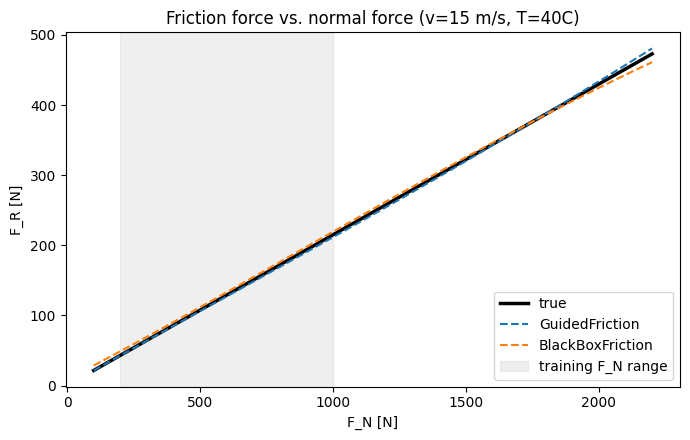

In [3]:
FN_range = torch.linspace(100, 2200, 100)
v_fixed = torch.full_like(FN_range, 15.0)
T_fixed = torch.full_like(FN_range, 40.0)
FR_true_curve = friction_force(true_mu(v_fixed, T_fixed), FN_range)
with torch.no_grad():
    FR_guided_curve = guided(v_fixed, FN_range, T_fixed)
    FR_bb_curve = blackbox(v_fixed, FN_range, T_fixed)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(FN_range, FR_true_curve, "k-", linewidth=2.5, label="true")
ax.plot(FN_range, FR_guided_curve, "--", label="GuidedFriction")
ax.plot(FN_range, FR_bb_curve, "--", label="BlackBoxFriction")
ax.axvspan(200, 1000, color="gray", alpha=0.12, label="training F_N range")
ax.set_xlabel("F_N [N]"); ax.set_ylabel("F_R [N]"); ax.legend()
ax.set_title("Friction force vs. normal force (v=15 m/s, T=40C)")
plt.tight_layout(); plt.show()


## 10. Evaluation

In [4]:
def eval_model(model, v, FN, T, FR_true):
    with torch.no_grad():
        pred = model(v, FN, T)
    return ((pred - FR_true) / FR_scale).pow(2).mean().item()

print(f"{'model':18s} {'train MSE':>12s} {'extrap F_N MSE':>16s}")
for name, model in [("GuidedFriction", guided), ("BlackBoxFriction", blackbox)]:
    tr = eval_model(model, v_tr, FN_tr, T_tr, FR_tr)
    te = eval_model(model, v_te, FN_te, T_te, FR_te)
    print(f"{name:18s} {tr:12.6f} {te:16.6f}")


model                 train MSE   extrap F_N MSE
GuidedFriction         0.000134         0.001097
BlackBoxFriction       0.000718         0.009941


## 11. Thermal feedback demonstration

A sustained-braking scenario: constant velocity and normal force over a 200s event, driving the (already-trained) `GuidedFriction` model, whose output heats a `LumpedThermal` model, whose *rising temperature feeds back into* `GuidedFriction`'s own $\mu(v,F_N,T)$ — a genuinely coupled simulation, not two separate plots. Thermal parameters ($C_{th}$, $hA$) are fixed at illustrative values here (not fit) — Notebook 09 is where a full train/evaluate treatment of every submodel together belongs; this section only has to demonstrate that the feedback loop runs and produces the right qualitative shape.

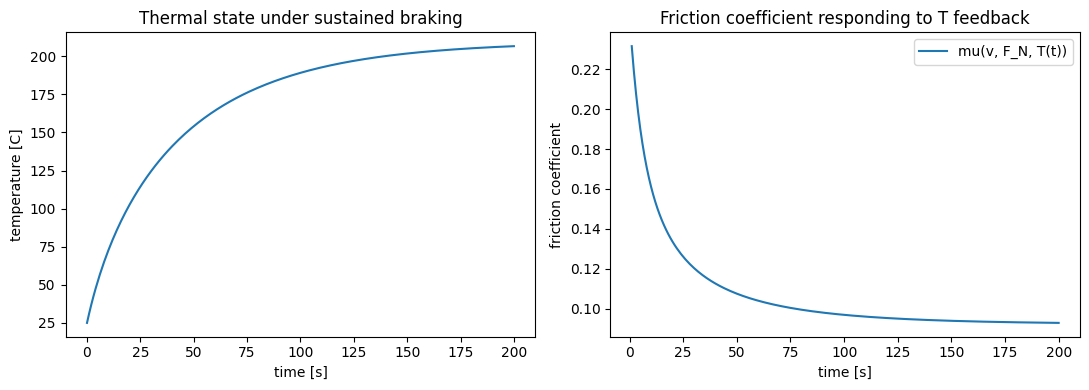

T: 25.0C -> 206.6C, mu: 0.2315 -> 0.0930


In [5]:
thermal = LumpedThermal(C_th_init=600.0, hA_init=8.0)
for p in thermal.parameters():
    p.requires_grad_(False)

v_brake, FN_brake, T_ambient = torch.tensor(20.0), torch.tensor(800.0), torch.tensor(25.0)
dt, T_dur = 1.0, 200
T_state = T_ambient.clone()
T_history, mu_history, FR_history = [T_state.item()], [], []

with torch.no_grad():
    for k in range(T_dur):
        mu_k = guided.mu(v_brake.unsqueeze(0), FN_brake.unsqueeze(0), T_state.unsqueeze(0)).squeeze(0)
        FR_k = friction_force(mu_k, FN_brake)
        P_loss_k = (FR_k * v_brake).abs()
        T_state = T_state + dt * thermal.rhs(T_state, P_loss_k, T_ambient)
        T_history.append(T_state.item())
        mu_history.append(mu_k.item())
        FR_history.append(FR_k.item())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t_axis = np.arange(T_dur + 1) * dt
axes[0].plot(t_axis, T_history)
axes[0].set_xlabel("time [s]"); axes[0].set_ylabel("temperature [C]"); axes[0].set_title("Thermal state under sustained braking")
axes[1].plot(t_axis[1:], mu_history, label="mu(v, F_N, T(t))")
axes[1].set_xlabel("time [s]"); axes[1].set_ylabel("friction coefficient"); axes[1].set_title("Friction coefficient responding to T feedback")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"T: {T_history[0]:.1f}C -> {T_history[-1]:.1f}C, mu: {mu_history[0]:.4f} -> {mu_history[-1]:.4f}")


## 12. Discussion

The friction comparison repeats a pattern this project has now seen in Notebooks 03, 04, and 07: hard-coding an exact, known relation ($F_R = \mu F_N$) and learning only the genuinely uncertain part ($\mu$) costs nothing on the training range and wins clearly on extrapolation — here, to normal-force values twice the training range. `BlackBoxFriction` has no structural reason to know that friction force should scale with normal force at all; it has to infer that from data, and outside the range it saw, it doesn't reliably.

The thermal feedback section is a demonstration, not a benchmark — its point is that the loop (friction heats the system, temperature changes friction) runs correctly end to end using an already-validated friction model and a structurally simple, physically-grounded thermal ODE. It also surfaces a genuine emergent behavior worth naming: temperature does not run away. With `mu` decreasing in $T$, rising temperature reduces friction, which reduces $P_{\text{loss}} = |F_R v|$, which slows further heating — a negative feedback loop that self-limits the temperature rise, visible in the simulated curve leveling off well below what constant-$\mu$ heating at the initial coefficient would have produced. That said, the 200s simulation drives $T$ up to roughly 207°C — far outside `GuidedFriction`'s training range of 20-80°C (Section 8) — so the friction coefficient's behavior there is itself an extrapolation, not a validated prediction; the qualitative self-limiting shape is a believable consequence of the model's structure, but the exact numbers past 80°C should not be trusted without recalibrating on data that actually covers that range. Separately, a quantitative fit of the thermal parameters themselves to a reference trajectory — the more rigorous, Notebook-01-style exercise — was tried during development and ran into a genuine identifiability issue worth naming honestly: a single constant-power step response under-determines $C_{th}$ and $hA$ independently (their ratio, the thermal time constant, is much better constrained than either alone) — the same class of finding as Notebook 01's, here for a 2-parameter system instead of a 12-parameter one.

## 13. Relevance for ATLAS

Both results transfer directly to ATLAS's assumed friction model: a guided (not black-box) friction coefficient is a low-risk, low-cost upgrade with a demonstrated extrapolation benefit, and the thermal feedback loop here is a minimal working version of exactly the $T \to \sigma$ / $T \to \mu$ feedback this project's target architecture calls for — the $T\to\sigma$ (conductivity, feeding into the Cauer/graph-Cauer skin-effect model) half is not built in this notebook and would require combining this thermal state with Notebooks 01/04's models directly, left for Notebook 09.

## 14. Next step

`09_atlas_small_combined_model.ipynb` — chain the Cauer/graph-Cauer skin-effect model (01/04), the magnetic circuit (03), the co-energy force (07), and this friction/thermal loop into one small combined model on synthetic ATLAS-like data, the culmination of every notebook so far.